# 03 - Model Training: Prediksi Signal BUY / SELL / HOLD

**Input:** `EURUSD_M15_cleaned.csv`  
**Output:** Model tersimpan di `models/signal_model.pkl`

**Strategi:**
- Algoritma: Random Forest + XGBoost (dibandingkan)
- Handle imbalanced: `class_weight='balanced'`
- Split: TimeSeriesSplit (80% train / 20% test) — tidak random
- Evaluasi: Precision, Recall, F1 per class + Confusion Matrix

## 1. Import Library

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, f1_score)
from sklearn.model_selection import TimeSeriesSplit
import joblib

try:
    import xgboost as xgb
    XGB_AVAILABLE = True
    print('XGBoost tersedia.')
except ImportError:
    XGB_AVAILABLE = False
    print('XGBoost tidak tersedia — hanya Random Forest.')

os.makedirs('models', exist_ok=True)
print('Libraries loaded.')

XGBoost tersedia.
Libraries loaded.


In [13]:
import sys
print(sys.executable)


c:\Users\baus12345\Desktop\robot-treding\venv\Scripts\python.exe


## 2. Load & Persiapkan Data

In [14]:
df = pd.read_csv('EURUSD_M15_cleaned.csv', index_col='datetime', parse_dates=True)
df = df.sort_index()

print(f'Shape: {df.shape}')
print(f'Range: {df.index.min()} → {df.index.max()}')
print(f'\nDistribusi signal:')
print(df['signal'].value_counts())

Shape: (100248, 28)
Range: 2021-12-16 10:30:00 → 2026-03-25 18:30:00

Distribusi signal:
signal
HOLD    84447
BUY      7967
SELL     7834
Name: count, dtype: int64


## 3. Feature Selection

In [15]:
# Fitur yang dipakai — hanya yang tersedia SAAT INI (no lookahead)
# Tidak pakai: sl, tp (derived dari future), signal_num
FEATURES = [
    # Harga relatif
    'body', 'upper_shadow', 'lower_shadow', 'candle_dir',
    'return', 'return_3', 'return_5',
    # Indikator momentum
    'rsi_14',
    'macd_line', 'macd_signal', 'macd_hist',
    # Trend
    'ema_9', 'ema_21', 'ema_50', 'ema_200',
    # Volatilitas
    'atr_14', 'bb_upper', 'bb_mid', 'bb_lower',
    # Volume
    'tick_vol', 'spread'
]

TARGET = 'signal'

# Tambah fitur turunan dari EMA (posisi relatif)
df['ema9_vs_21']   = df['ema_9']   - df['ema_21']
df['ema50_vs_200'] = df['ema_50']  - df['ema_200']
df['close_vs_bb']  = df['close']   - df['bb_mid']
df['close_vs_ema21'] = df['close'] - df['ema_21']

FEATURES += ['ema9_vs_21', 'ema50_vs_200', 'close_vs_bb', 'close_vs_ema21']

# Pastikan tidak ada NaN
df_model = df[FEATURES + [TARGET]].dropna().copy()

print(f'Total fitur: {len(FEATURES)}')
print(f'Total baris: {len(df_model):,}')
print(f'Fitur: {FEATURES}')

Total fitur: 25
Total baris: 100,248
Fitur: ['body', 'upper_shadow', 'lower_shadow', 'candle_dir', 'return', 'return_3', 'return_5', 'rsi_14', 'macd_line', 'macd_signal', 'macd_hist', 'ema_9', 'ema_21', 'ema_50', 'ema_200', 'atr_14', 'bb_upper', 'bb_mid', 'bb_lower', 'tick_vol', 'spread', 'ema9_vs_21', 'ema50_vs_200', 'close_vs_bb', 'close_vs_ema21']


## 4. Train / Test Split (Time Series)

In [16]:
# 80% train, 20% test — berurutan (tidak random)
split_idx = int(len(df_model) * 0.80)

train_df = df_model.iloc[:split_idx]
test_df  = df_model.iloc[split_idx:]

X_train = train_df[FEATURES]
y_train = train_df[TARGET]
X_test  = test_df[FEATURES]
y_test  = test_df[TARGET]

print(f'Train: {len(train_df):,} baris  ({train_df.index.min().date()} → {train_df.index.max().date()})')
print(f'Test : {len(test_df):,} baris  ({test_df.index.min().date()} → {test_df.index.max().date()})')
print(f'\nDistribusi train:')
print(y_train.value_counts())
print(f'\nDistribusi test:')
print(y_test.value_counts())

Train: 80,198 baris  (2021-12-16 → 2025-06-03)
Test : 20,050 baris  (2025-06-03 → 2026-03-25)

Distribusi train:
signal
HOLD    67570
BUY      6384
SELL     6244
Name: count, dtype: int64

Distribusi test:
signal
HOLD    16877
SELL     1590
BUY      1583
Name: count, dtype: int64


## 5. Training — Random Forest

In [17]:
print('Training Random Forest...')

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=20,
    class_weight='balanced',   # handle imbalanced
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print('\n=== Random Forest — Classification Report ===')
print(classification_report(y_test, y_pred_rf, digits=4))

f1_rf = f1_score(y_test, y_pred_rf, average='macro')
print(f'Macro F1 Score: {f1_rf:.4f}')

Training Random Forest...

=== Random Forest — Classification Report ===
              precision    recall  f1-score   support

         BUY     0.0991    0.1548    0.1208      1583
        HOLD     0.8912    0.3373    0.4894     16877
        SELL     0.0906    0.6377    0.1587      1590

    accuracy                         0.3467     20050
   macro avg     0.3603    0.3766    0.2563     20050
weighted avg     0.7652    0.3467    0.4341     20050

Macro F1 Score: 0.2563


## 6. Training — XGBoost (jika tersedia)

In [18]:
if XGB_AVAILABLE:
    le = LabelEncoder()
    y_train_enc = le.fit_transform(y_train)
    y_test_enc  = le.transform(y_test)

    # Hitung scale_pos_weight per class
    counts = np.bincount(y_train_enc)
    total  = len(y_train_enc)

    xgb_model = xgb.XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        use_label_encoder=False,
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1
    )
    xgb_model.fit(
        X_train, y_train_enc,
        sample_weight=np.where(y_train_enc == le.transform(['HOLD'])[0], 0.3, 1.0),
        eval_set=[(X_test, y_test_enc)],
        verbose=False
    )

    y_pred_xgb_enc = xgb_model.predict(X_test)
    y_pred_xgb = le.inverse_transform(y_pred_xgb_enc)

    print('\n=== XGBoost — Classification Report ===')
    print(classification_report(y_test, y_pred_xgb, digits=4))

    f1_xgb = f1_score(y_test, y_pred_xgb, average='macro')
    print(f'Macro F1 Score: {f1_xgb:.4f}')
else:
    print('XGBoost tidak tersedia — skip.')
    f1_xgb = 0


=== XGBoost — Classification Report ===
              precision    recall  f1-score   support

         BUY     0.1043    0.0581    0.0746      1583
        HOLD     0.8596    0.7891    0.8228     16877
        SELL     0.1026    0.2371    0.1432      1590

    accuracy                         0.6876     20050
   macro avg     0.3555    0.3614    0.3469     20050
weighted avg     0.7399    0.6876    0.7099     20050

Macro F1 Score: 0.3469


## 7. Pilih Model Terbaik & Confusion Matrix

Random Forest F1 : 0.2563
XGBoost F1       : 0.3469

✅ Model terbaik: XGBoost


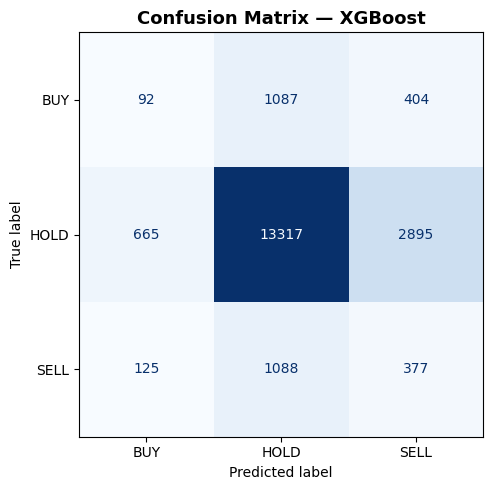

In [19]:
print(f'Random Forest F1 : {f1_rf:.4f}')
if XGB_AVAILABLE:
    print(f'XGBoost F1       : {f1_xgb:.4f}')
    best_model  = xgb_model if f1_xgb >= f1_rf else rf_model
    best_name   = 'XGBoost' if f1_xgb >= f1_rf else 'Random Forest'
    y_pred_best = y_pred_xgb if f1_xgb >= f1_rf else y_pred_rf
else:
    best_model  = rf_model
    best_name   = 'Random Forest'
    y_pred_best = y_pred_rf

print(f'\n✅ Model terbaik: {best_name}')

# Confusion Matrix
labels = ['BUY', 'HOLD', 'SELL']
cm = confusion_matrix(y_test, y_pred_best, labels=labels)

fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix — {best_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Feature Importance

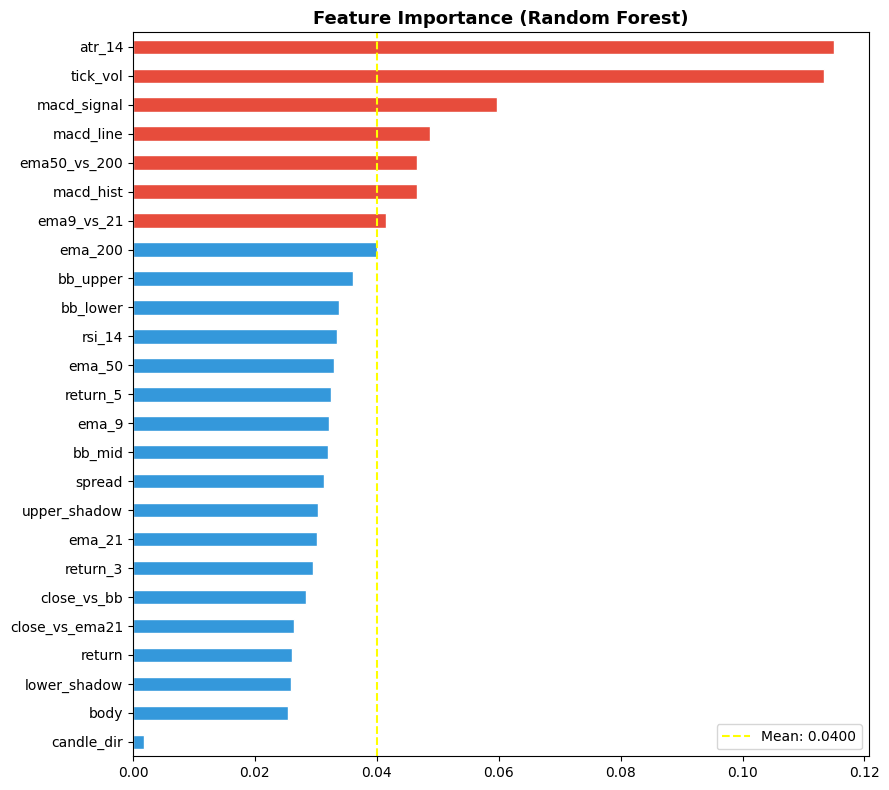

Top 10 fitur paling penting:
  atr_14                : 0.1149
  tick_vol              : 0.1133
  macd_signal           : 0.0597
  macd_line             : 0.0488
  ema50_vs_200          : 0.0467
  macd_hist             : 0.0466
  ema9_vs_21            : 0.0416
  ema_200               : 0.0400
  bb_upper              : 0.0360
  bb_lower              : 0.0338


In [20]:
# Ambil feature importance dari Random Forest
fi = pd.Series(rf_model.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 8))
colors = ['#e74c3c' if v >= fi.quantile(0.75) else '#3498db' for v in fi.values]
fi.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('Feature Importance (Random Forest)', fontsize=13, fontweight='bold')
ax.axvline(fi.mean(), color='yellow', linestyle='--', label=f'Mean: {fi.mean():.4f}')
ax.legend()
plt.tight_layout()
plt.show()

print('Top 10 fitur paling penting:')
for feat, val in fi.sort_values(ascending=False).head(10).items():
    print(f'  {feat:22s}: {val:.4f}')

## 9. Backtest Sederhana — Simulasi Trading

Total trade   : 4,558
Win           : 2,257
Win rate      : 49.5%
Total return  : -3.57%


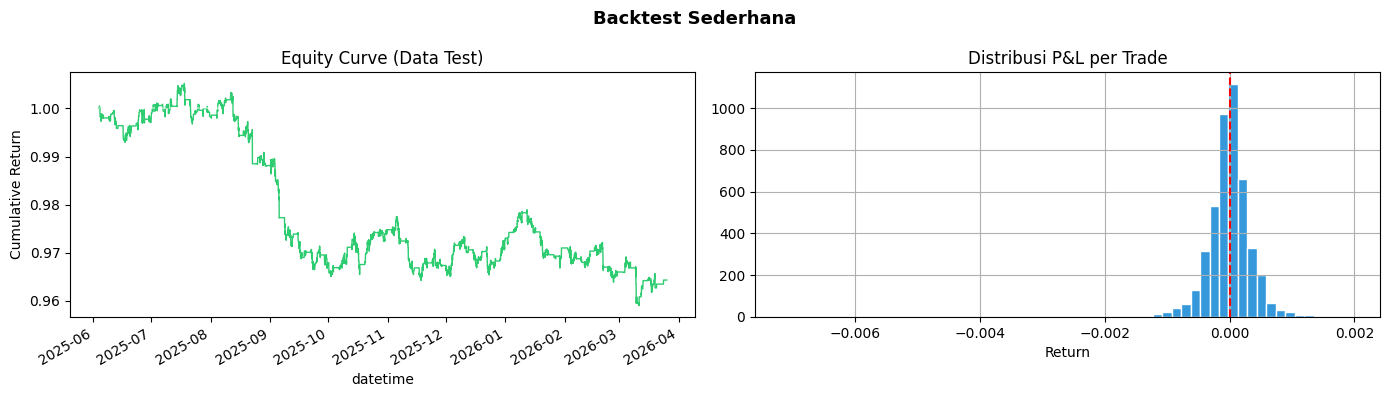

In [21]:
# Simulasi trading pada data test
bt = df_model.iloc[split_idx:].copy()
bt['close'] = df.loc[bt.index, 'close']
bt['pred']  = y_pred_best

bt['next_return'] = bt['close'].pct_change().shift(-1)

bt['trade_pnl'] = np.where(
    bt['pred'] == 'BUY',   bt['next_return'],
    np.where(
    bt['pred'] == 'SELL', -bt['next_return'], 0)
)

trades       = bt[bt['pred'] != 'HOLD'].copy()
total_trades = len(trades)
win_trades   = (trades['trade_pnl'] > 0).sum()
win_rate     = win_trades / total_trades * 100 if total_trades > 0 else 0
cumulative   = (1 + bt['trade_pnl']).cumprod()

print(f'Total trade   : {total_trades:,}')
print(f'Win           : {win_trades:,}')
print(f'Win rate      : {win_rate:.1f}%')
print(f'Total return  : {(cumulative.iloc[-1] - 1) * 100:.2f}%')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
cumulative.plot(ax=axes[0], color='#2ecc71', linewidth=1)
axes[0].axhline(1.0, color='white', linestyle='--', alpha=0.5)
axes[0].set_title('Equity Curve (Data Test)')
axes[0].set_ylabel('Cumulative Return')
trades['trade_pnl'].hist(bins=60, ax=axes[1], color='#3498db', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Distribusi P&L per Trade')
axes[1].set_xlabel('Return')
plt.suptitle('Backtest Sederhana', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Simpan Model

In [22]:
# Simpan model terbaik
model_path   = f'models/signal_model.pkl'
feature_path = f'models/feature_list.pkl'

joblib.dump(best_model, model_path)
joblib.dump(FEATURES, feature_path)

# Simpan label encoder jika XGBoost
if XGB_AVAILABLE and best_name == 'XGBoost':
    joblib.dump(le, 'models/label_encoder.pkl')
    print('Label encoder disimpan: models/label_encoder.pkl')

print(f'Model disimpan   : {model_path}')
print(f'Feature list     : {feature_path}')
print(f'Model            : {best_name}')
print(f'Jumlah fitur     : {len(FEATURES)}')
print(f'Macro F1 (test)  : {max(f1_rf, f1_xgb if XGB_AVAILABLE else 0):.4f}')
print(f'Win rate backtest: {win_rate:.1f}%')
print('\n✅ Model siap diintegrasikan ke trade_signal!')

Label encoder disimpan: models/label_encoder.pkl
Model disimpan   : models/signal_model.pkl
Feature list     : models/feature_list.pkl
Model            : XGBoost
Jumlah fitur     : 25
Macro F1 (test)  : 0.3469
Win rate backtest: 49.5%

✅ Model siap diintegrasikan ke trade_signal!
